In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('../data/diabetes_risk_data_300.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

print("\nTarget Distribution:")
print(df['Outcome'].value_counts())
print(f"\nClass Balance: {df['Outcome'].value_counts(normalize=True)}")

Dataset Shape: (300, 9)

First 5 rows:
    Age   BMI  Glucose  BloodPressure  Insulin  SkinThickness  Pregnancies  \
0  58.0  32.1    175.0           86.0    288.0           59.0          7.0   
1  60.0  36.9    171.0           71.0    101.0           37.0          7.0   
2  36.0  35.2    194.0           87.0    276.0           14.0          8.0   
3  22.0  18.1     89.0           74.0    373.0           15.0          0.0   
4  25.0   NaN    188.0            NaN    607.0           53.0          5.0   

   DiabetesPedigreeFunction  Outcome  
0                     1.256        1  
1                     1.318        1  
2                       NaN        1  
3                     0.775        0  
4                     1.615        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                     

Missing Values per Column:
Age                         21
BMI                         25
Glucose                     23
BloodPressure               23
Insulin                     24
SkinThickness               22
Pregnancies                 25
DiabetesPedigreeFunction    22
Outcome                      0
dtype: int64

Total Missing Values: 185
Percentage Missing: 6.85%


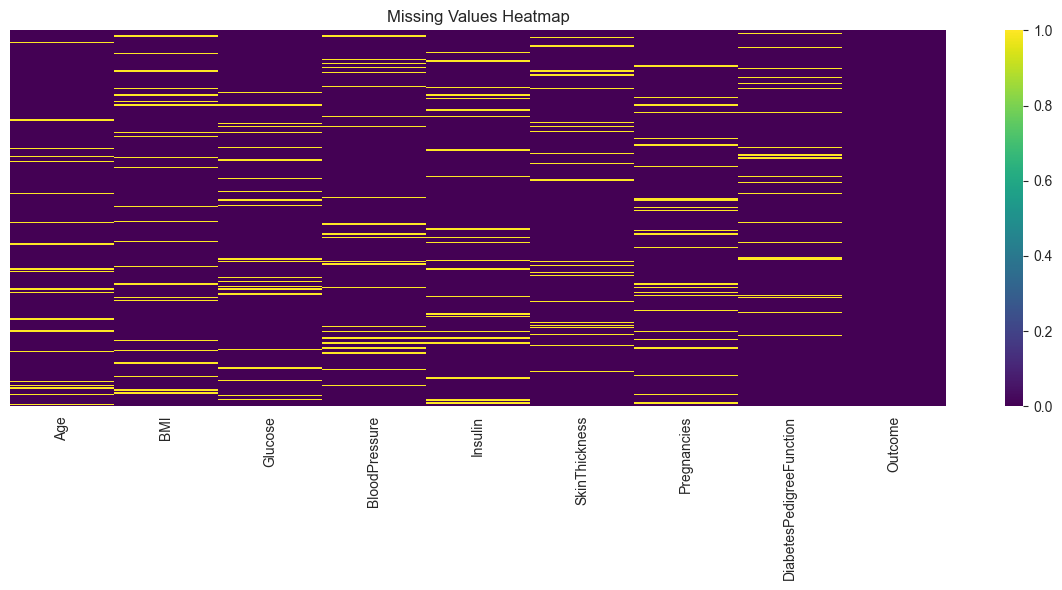

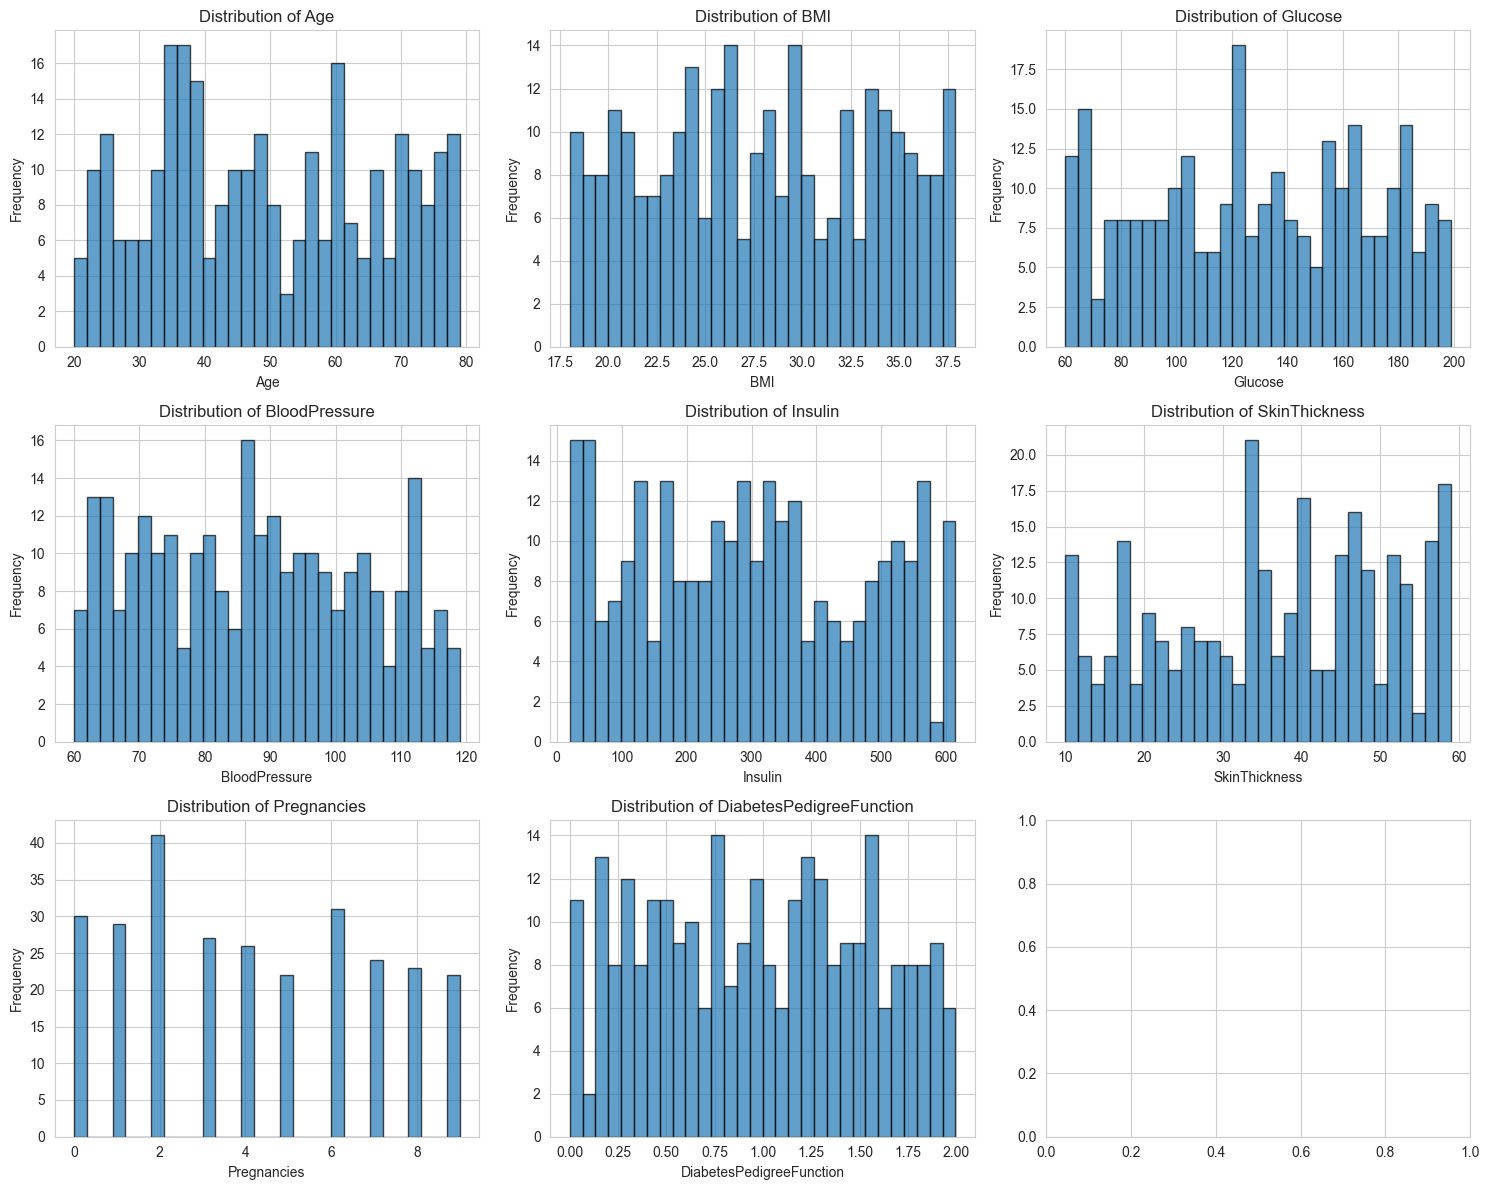

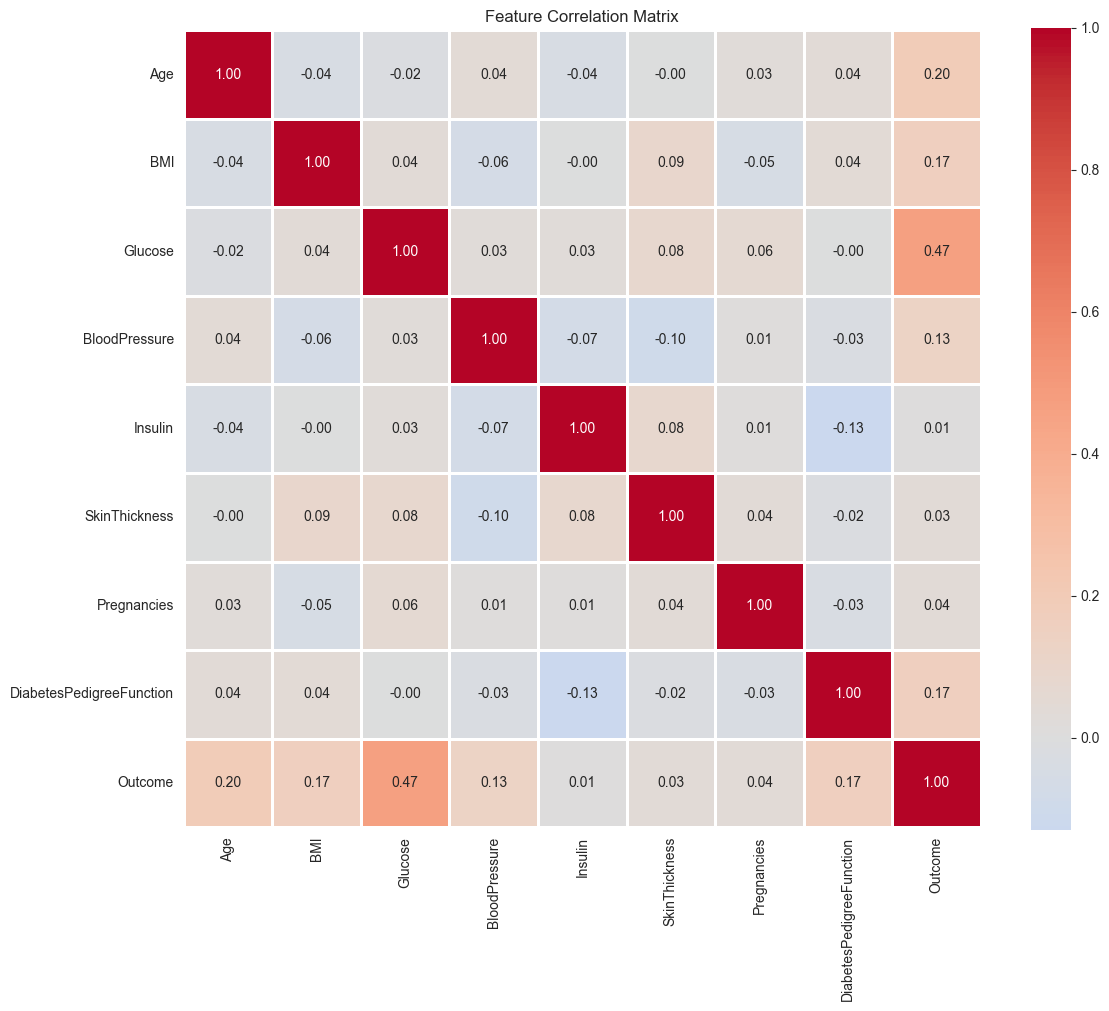

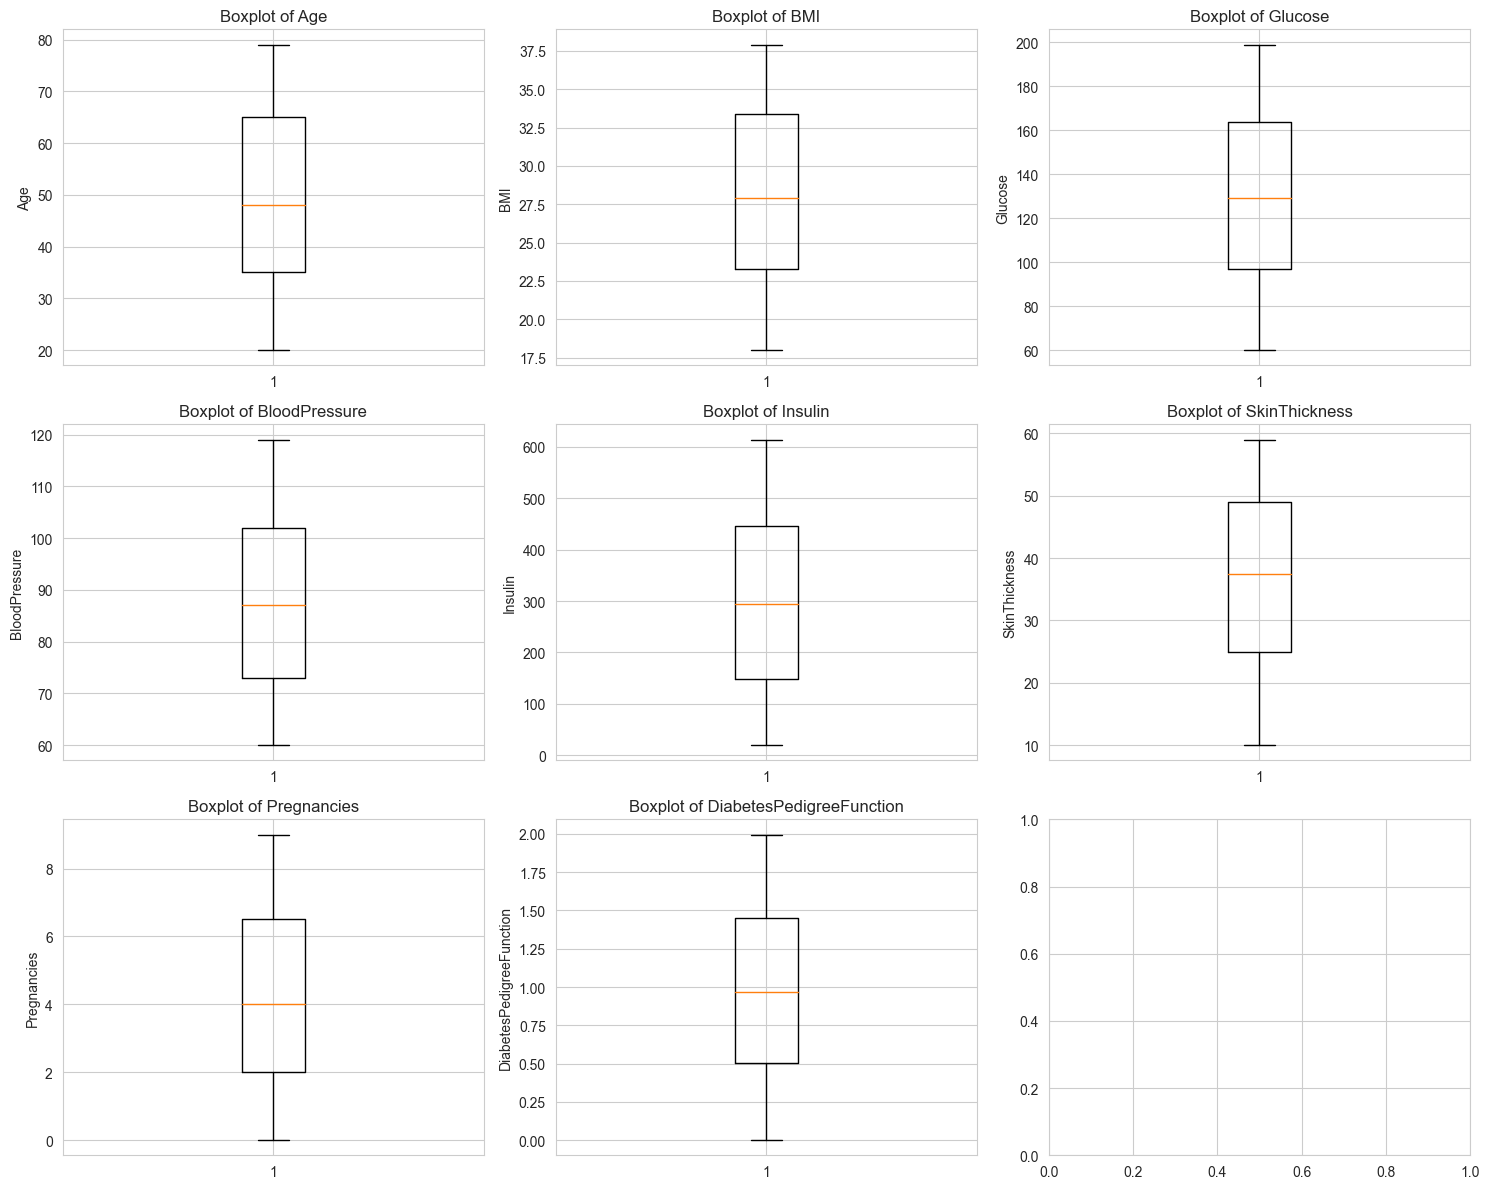

In [6]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
print(f"Percentage Missing: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
# plt.savefig('../models/missing_values_heatmap.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

# Distribution of features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns[:-1]):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
# plt.savefig('../models/feature_distributions.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

# Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
# plt.savefig('../models/correlation_matrix.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

# Boxplots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns[:-1]):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
# plt.savefig('../models/outlier_boxplots.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

In [7]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

# Handle missing values - using mean imputation
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("✓ Missing values imputed using mean strategy")

# Feature scaling - StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("✓ Features scaled using StandardScaler")

# Convert back to dataframe for easier handling
X_train_processed = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_processed = pd.DataFrame(X_test_scaled, columns=X.columns)

Features shape: (300, 8)
Target shape: (300,)
Training set size: 240
Test set size: 60

Training set class distribution:
Outcome
1    170
0     70
Name: count, dtype: int64

Test set class distribution:
Outcome
1    43
0    17
Name: count, dtype: int64
✓ Missing values imputed using mean strategy
✓ Features scaled using StandardScaler


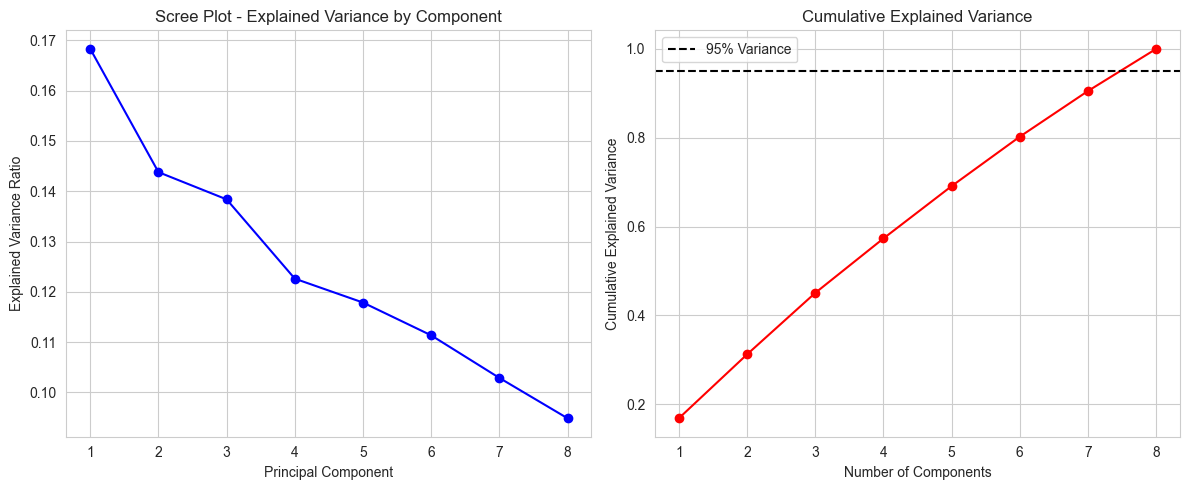

Feature Importance Scores (SelectKBest):
                     Feature      Score
2                   Glucose  64.762239
0                       Age  11.207909
1                       BMI   6.662365
7  DiabetesPedigreeFunction   5.293464
3             BloodPressure   3.734719
4                   Insulin   0.378881
5             SkinThickness   0.023538
6               Pregnancies   0.008472

Top 5 Selected Features: ['Glucose', 'Age', 'BMI', 'DiabetesPedigreeFunction', 'BloodPressure']

Reduced feature set shape: (240, 5)


In [8]:
# Apply PCA to understand variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Plot explained variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
          pca_full.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Explained Variance by Component')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
          np.cumsum(pca_full.explained_variance_ratio_), 'ro-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.95, color='k', linestyle='--', label='95% Variance')
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.savefig('../models/pca_variance_analysis.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

# Method 1: SelectKBest with f_classif
selector_kbest = SelectKBest(score_func=f_classif, k=5)
selector_kbest.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector_kbest.scores_
}).sort_values('Score', ascending=False)

print("Feature Importance Scores (SelectKBest):\n", feature_scores)

# Select top 5 features based on SelectKBest
top_features = feature_scores.head(5)['Feature'].tolist()
print(f"\nTop 5 Selected Features: {top_features}")

# Create reduced datasets (for potential future use)
X_train_selected = X_train_processed[top_features]
X_test_selected = X_test_processed[top_features]

print(f"\nReduced feature set shape: {X_train_selected.shape}")

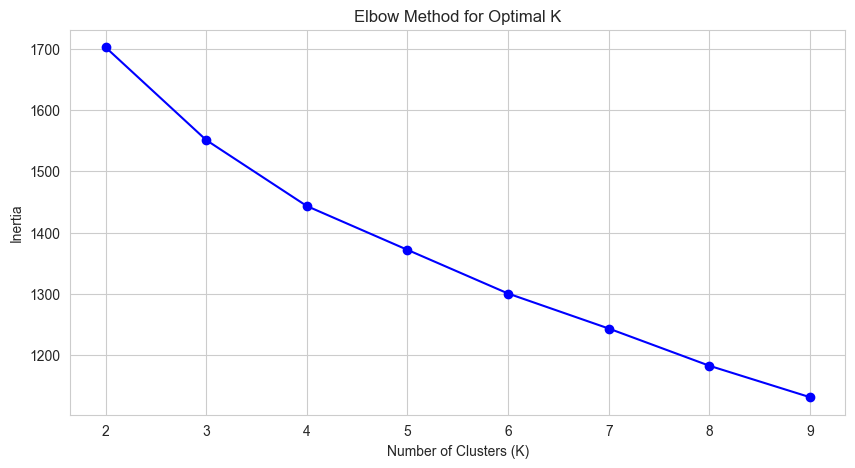

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


K-Means with K=3


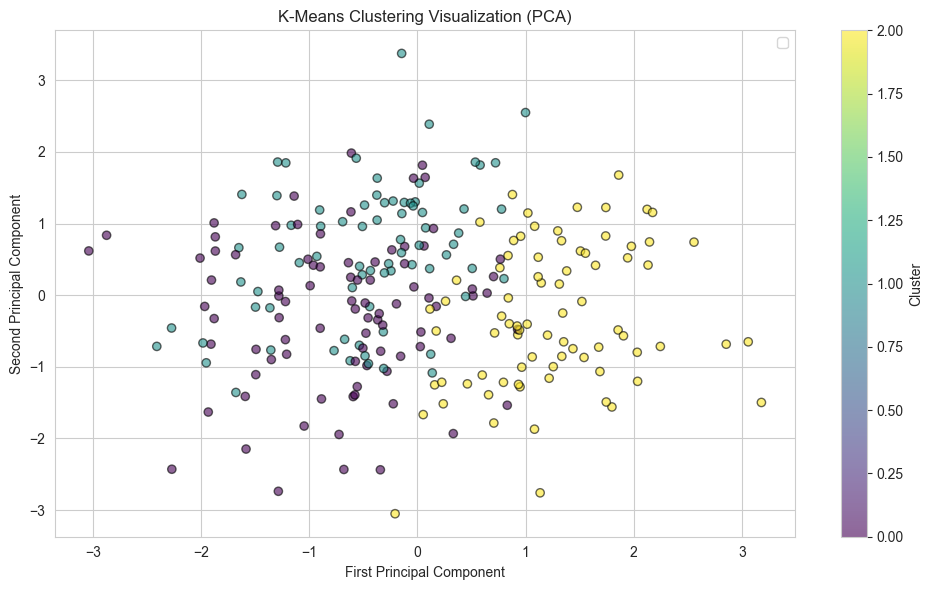

In [14]:
# Determine optimal K using elbow method
inertias = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
# plt.savefig('../models/kmeans_elbow.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

# Apply K-Means with optimal K (let's use 3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)

print(f"K-Means with K={optimal_k}")

# Visualize clusters using PCA (2 components for visualization)
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                      c=train_clusters, cmap='viridis', alpha=0.6, edgecolors='k')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-Means Clustering Visualization (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
# plt.savefig('../models/kmeans_clusters.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

In [9]:
# --- LOGISTIC REGRESSION ---
print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)

lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

lr = LogisticRegression(max_iter=1000, random_state=42)
lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_scaled, y_train)
lr_best = lr_grid.best_estimator_
y_test_pred_lr = lr_best.predict(X_test_scaled)
y_test_proba_lr = lr_best.predict_proba(X_test_scaled)[:, 1]

print(f"Best LR ROC-AUC Score: {lr_grid.best_score_:.4f}")
print("Test LR Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}, ROC-AUC: {roc_auc_score(y_test, y_test_proba_lr):.4f}")

# --- RANDOM FOREST ---
print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_
y_test_pred_rf = rf_best.predict(X_test_scaled)
y_test_proba_rf = rf_best.predict_proba(X_test_scaled)[:, 1]

print(f"Best RF ROC-AUC Score: {rf_grid.best_score_:.4f}")
print("Test RF Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}, ROC-AUC: {roc_auc_score(y_test, y_test_proba_rf):.4f}")

# --- SUPPORT VECTOR MACHINE (SVM) ---
print("\n" + "="*50)
print("SUPPORT VECTOR MACHINE (SVM)")
print("="*50)

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm = SVC(probability=True, random_state=42)
svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_
y_test_pred_svm = svm_best.predict(X_test_scaled)
y_test_proba_svm = svm_best.predict_proba(X_test_scaled)[:, 1]

print(f"Best SVM ROC-AUC Score: {svm_grid.best_score_:.4f}")
print("Test SVM Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_svm):.4f}, ROC-AUC: {roc_auc_score(y_test, y_test_proba_svm):.4f}")


LOGISTIC REGRESSION
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LR ROC-AUC Score: 0.8357
Test LR Performance:
Accuracy: 0.7833, ROC-AUC: 0.7661

RANDOM FOREST
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best RF ROC-AUC Score: 0.8458
Test RF Performance:
Accuracy: 0.7833, ROC-AUC: 0.8126

SUPPORT VECTOR MACHINE (SVM)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVM ROC-AUC Score: 0.8282
Test SVM Performance:
Accuracy: 0.7500, ROC-AUC: 0.7483



MODEL COMPARISON
              Model  Accuracy  Precision  ROC-AUC
Logistic Regression  0.783333   0.812500 0.766074
      Random Forest  0.783333   0.800000 0.812585
                SVM  0.750000   0.804348 0.748290


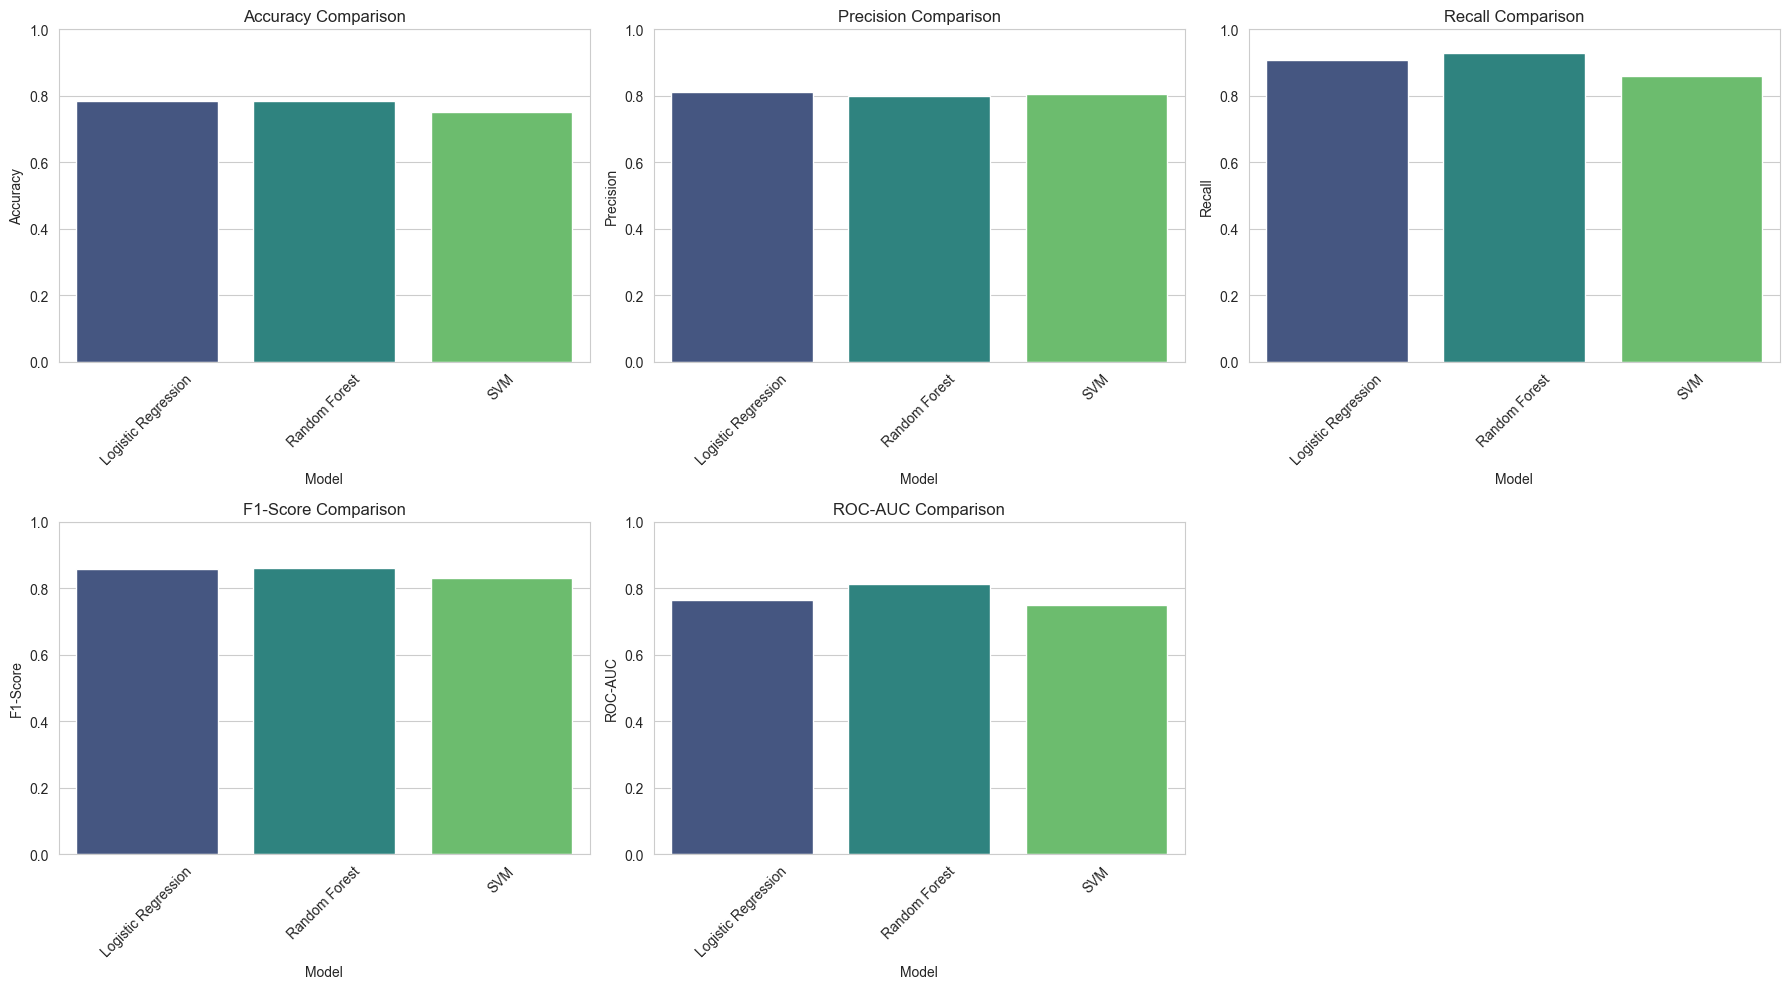

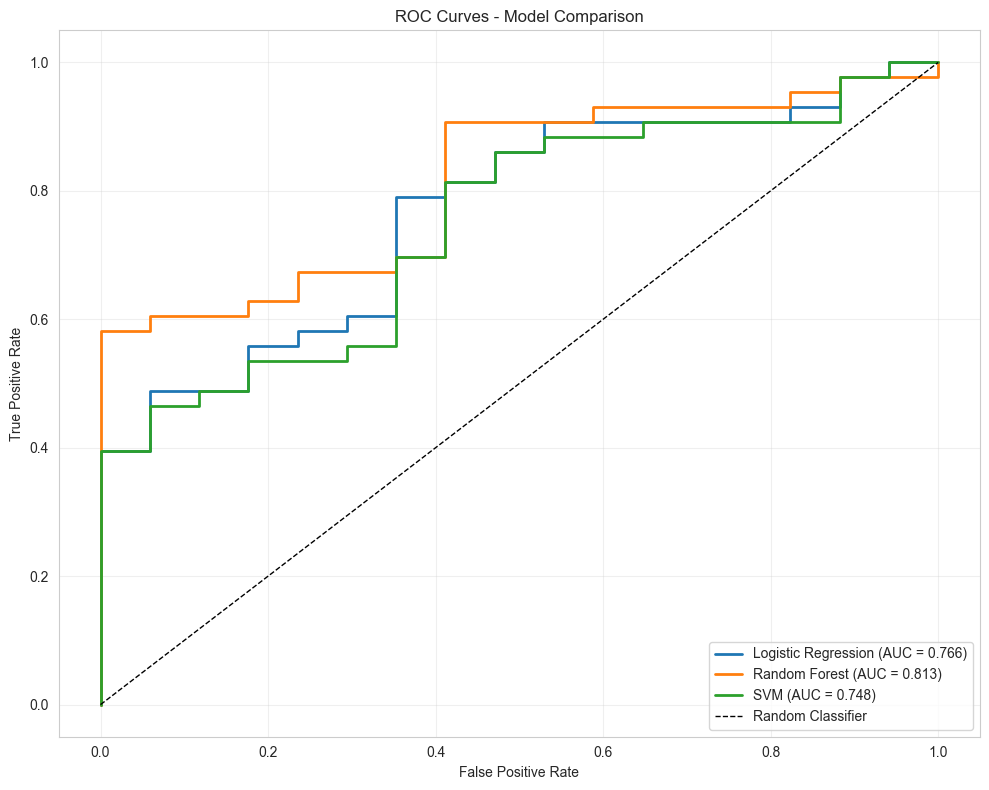

In [15]:
# Compare all models
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_rf),
        accuracy_score(y_test, y_test_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_rf),
        precision_score(y_test, y_test_pred_svm)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_test_proba_lr),
        roc_auc_score(y_test, y_test_proba_rf),
        roc_auc_score(y_test, y_test_proba_svm)
    ]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(model_comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
y_test_pred_list = [y_test_pred_lr, y_test_pred_rf, y_test_pred_svm] # Added missing pred variables

# Re-calculate missing metrics for comparison table
model_comparison['Recall'] = [recall_score(y_test, p) for p in y_test_pred_list]
model_comparison['F1-Score'] = [f1_score(y_test, p) for p in y_test_pred_list]


for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    sns.barplot(data=model_comparison, x='Model', y=metric, ax=ax, palette='viridis')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)

fig.delaxes(axes[1, 2])
plt.tight_layout()
# plt.savefig('../models/model_comparison.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

# ROC Curves comparison
plt.figure(figsize=(10, 8))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_test_proba_lr):.3f})', linewidth=2)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_test_proba_rf):.3f})', linewidth=2)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_test_proba_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, y_test_proba_svm):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('../models/roc_curves_comparison.png', dpi=300, bbox_inches='tight') # Uncomment this if you want to save the image
plt.show()

In [11]:
# Determine best model based on ROC-AUC
best_model_idx = model_comparison['ROC-AUC'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']

print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"ROC-AUC Score: {model_comparison.loc[best_model_idx, 'ROC-AUC']:.4f}")
print(f"{'='*70}")

# Select the best model
if best_model_name == 'Logistic Regression':
    best_model = lr_best
elif best_model_name == 'Random Forest':
    best_model = rf_best
else:
    best_model = svm_best

# Save model artifacts (Ensure the '../models/' directory exists!)
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(imputer, '../models/imputer.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')
joblib.dump(lr_best, '../models/logistic_regression_model.pkl')
joblib.dump(rf_best, '../models/random_forest_model.pkl')
joblib.dump(svm_best, '../models/svm_model.pkl')

print("\n✓ All model artifacts saved successfully!")

# Final Summary (Re-using parts of Part 4's logic)
print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"\n📊 Dataset Information:")
print(f"  - Total samples: {df.shape[0]}")
print(f"  - Training set: {X_train.shape[0]} samples")

print(f"\n🔍 Feature Engineering:")
print(f"  - Top 5 important features: {', '.join(top_features)}")
print(f"  - PCA components for 95% variance: {np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1}")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"  ROC-AUC: {model_comparison.loc[best_model_idx, 'ROC-AUC']:.4f}")
print("\n✅ All steps complete.")


BEST MODEL: Random Forest
ROC-AUC Score: 0.8126

✓ All model artifacts saved successfully!

PROJECT SUMMARY

📊 Dataset Information:
  - Total samples: 300
  - Training set: 240 samples

🔍 Feature Engineering:
  - Top 5 important features: Glucose, Age, BMI, DiabetesPedigreeFunction, BloodPressure
  - PCA components for 95% variance: 8

🏆 Best Model: Random Forest
  ROC-AUC: 0.8126

✅ All steps complete.
